Mellynda Noor Romadhoni

A11.2022.14027 

Penambangan Data ( Data Mining 4519)

UAS

Judul:
Analisis dan Prediksi Kasus Homicide dengan Model Machine Learning

Topik:
Pemanfaatan algoritma machine learning untuk menganalisis dan memprediksi jumlah kasus pembunuhan (homicide) berdasarkan data lokasi, wilayah, subwilayah, dan variabel numerik lainnya.

Permasalahan:
Meningkatnya angka pembunuhan menjadi perhatian global, dan pemahaman pola pada data historis dapat membantu pemerintah dan lembaga terkait untuk mengelola sumber daya serta mengambil langkah pencegahan yang efektif.

Tujuan:
Melakukan eksplorasi data terkait kasus pembunuhan.
Membuat model machine learning untuk memprediksi jumlah kasus pembunuhan di masa depan berdasarkan pola historis.
Mengevaluasi performa model menggunakan metrik MAE dan R².
Model yang Digunakan:
Decision Tree Regressor
Random Forest Regressor


Alur Penjelasan (Bagan):

Pengenalan dan Permasalahan

Eksplorasi Data (EDA)

Proses Features Dataset

Proses Learning/Modelling

Evaluasi Model

Diskusi dan Kesimpulan

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


EDA

1.Analisis Statistik: Distribusi numerik (Rate, Count, Year).
2.Visualisasi:

Histogram untuk distribusi data numerik.

Heatmap korelasi antar variabel numerik.

Boxplot untuk mendeteksi outlier.


In [27]:
# Load dataset
file_path = r'D:\Semester 5\Penambangan Data\-\Homicide_Analysis-main\Homicide_Analysis-main\homicide.csv'
try:
    homicide_data = pd.read_csv(file_path)  # Memuat dataset dari file CSV
    print("Dataset berhasil dimuat.")
except FileNotFoundError:
    print("File tidak ditemukan. Pastikan jalur file sudah benar.")
    raise
except Exception as e:
    print("Error saat memuat dataset:", e)
    raise


Dataset berhasil dimuat.


In [29]:
# Informasi Umum
if 'homicide_data' in locals():
    print("\nDataset Info:")
    homicide_data.info()

    print("\nMissing Values per Column:")
    print(homicide_data.isnull().sum())

    print("\nStatistical Summary:")
    print(homicide_data.describe())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Location   195 non-null    object 
 1   Region     195 non-null    object 
 2   Subregion  195 non-null    object 
 3   Rate       195 non-null    float64
 4   Count      195 non-null    int64  
 5   Year       195 non-null    int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 9.3+ KB

Missing Values per Column:
Location     0
Region       0
Subregion    0
Rate         0
Count        0
Year         0
dtype: int64

Statistical Summary:
             Rate         Count         Year
count  195.000000    195.000000   195.000000
mean     6.845128   1942.800000  2017.420513
std      9.600060   6553.343376     3.589445
min      0.000000      0.000000  2006.000000
25%      1.100000     28.000000  2016.000000
50%      2.600000    128.000000  2019.000000
75%      7.850000    785.000000

In [30]:
# Visualisasi Distribusi Kolom Numerik
plt.figure(figsize=(15, 5))

 

<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

Text(0.5, 0, 'Rate')

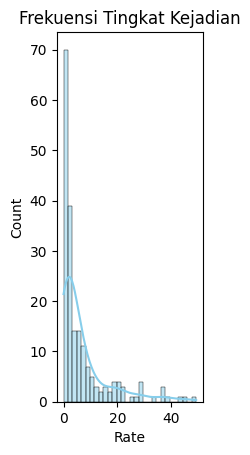

In [40]:
 # Distribusi kolom "Rate"
plt.subplot(1, 3, 1)
sns.histplot(homicide_data['Rate'], kde=True, bins=30, color='skyblue')
plt.title('Frekuensi Tingkat Kejadian') # fokusnya pada tingkat atau rasio pembunuhan per penduduk.
plt.xlabel('Rate')

Text(0.5, 0, 'Count')

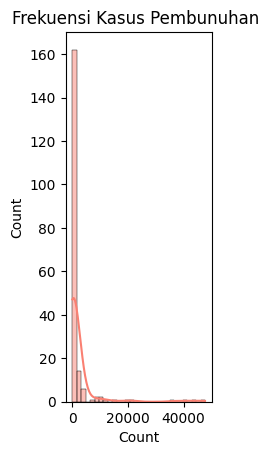

In [39]:
# Distribusi kolom "Count"
plt.subplot(1, 3, 2)
sns.histplot(homicide_data['Count'], kde=True, bins=30, color='salmon')
plt.title('Frekuensi Kasus Pembunuhan ') #fokusnya pada jumlah kasus secara total.
plt.xlabel('Count')

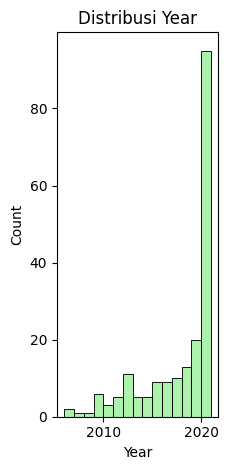

In [ ]:
 # Distribusi kolom "Year"
plt.subplot(1, 3, 3)
sns.histplot(homicide_data['Year'], kde=False, bins=15, color='lightgreen')
plt.title('Distribusi Year') #Perubahan Data Berdasarkan Tahun 
# tingkat kasus pembunuhan untuk setiap tahun.
plt.xlabel('Year')

plt.tight_layout()
plt.show()

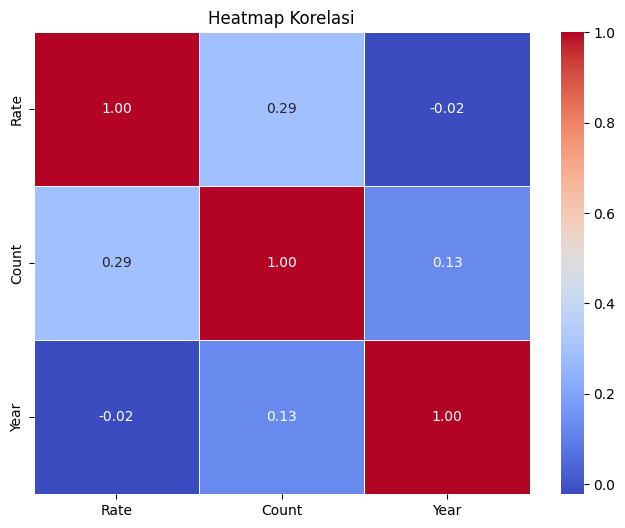

In [44]:
# Korelasi Antar Variabel Numerik
plt.figure(figsize=(8, 6))

# Memilih hanya kolom numerik
numeric_columns = homicide_data.select_dtypes(include=['float64', 'int64'])

# Menghitung matriks korelasi
correlation_matrix = numeric_columns.corr()

# Visualisasi heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi')
plt.show()


In [45]:
#deteksi outlier dengan boxplot 
plt.figure(figsize=(15,5))

<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

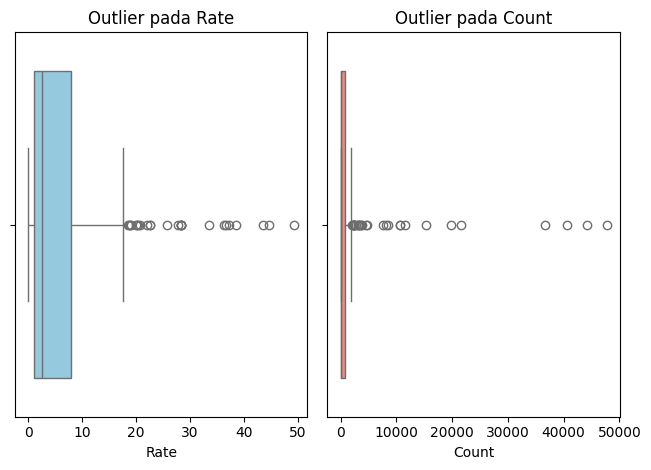

In [53]:
# Boxplot kolom "Rate"
plt.subplot(1, 2, 1)
sns.boxplot(data=homicide_data, x='Rate', color='skyblue')
plt.title('Outlier pada Rate')

# Boxplot kolom "Count"
plt.subplot(1, 2, 2)
sns.boxplot(data=homicide_data, x='Count', color='salmon')
plt.title('Outlier pada Count')

plt.tight_layout()
plt.show()

Features Processing

Proses Features Dataset:

1.One-Hot Encoding: Untuk fitur kategorikal (Location, Region, Subregion).

2.Scaling: Untuk fitur numerik (Rate, Count).

3.Split Dataset: Membagi data menjadi data latih (80%) dan uji (20%).

In [54]:
# Import library yang diperlukan
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

In [55]:
# Load dataset
file_path = r'D:\Semester 5\Penambangan Data\-\Homicide_Analysis-main\Homicide_Analysis-main\homicide.csv'
homicide_data = pd.read_csv(file_path)


In [56]:
# Identifikasi fitur numerik dan kategorikal
numerical_features = ['Rate', 'Count']
categorical_features = ['Location', 'Region', 'Subregion']

In [58]:
# Pipeline untuk fitur numerik
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Pipeline untuk fitur kategorikal
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


In [59]:
# Gabungkan transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


In [60]:
# Membagi dataset menjadi fitur (X) dan target (y)
X = homicide_data.drop(['Year'], axis=1)  # Menghapus kolom target
y = homicide_data['Year']


In [62]:
# Split dataset menjadi data latih dan uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Transformasi dataset
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print("Proses features dataset selesai. Data sudah di-scaling dan di-one-hot encoding.")
# Informasi hasil transformasi
print(f"Dimensi data latih setelah transformasi: {X_train_transformed.shape}")
print(f"Dimensi data uji setelah transformasi: {X_test_transformed.shape}")


Proses features dataset selesai. Data sudah di-scaling dan di-one-hot encoding.
Dimensi data latih setelah transformasi: (156, 182)
Dimensi data uji setelah transformasi: (39, 182)


Proses Learning / Modelling

Decision Tree Regressor:
Menggunakan algoritma pohon keputusan untuk membuat model yang memprediksi nilai Year.

Random Forest Regressor:
Membuat model ensemble yang menggabungkan banyak pohon keputusan untuk meningkatkan akurasi prediksi.

Training dan Prediksi:
Data latih digunakan untuk melatih model.
Data uji digunakan untuk mengevaluasi performa model.

Linear Regression

In [63]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [64]:
# Inisialisasi model regresi linear
model = LinearRegression()

# Melatih model dengan data latih
model.fit(X_train_transformed, y_train)

# Melakukan prediksi pada data uji
y_pred = model.predict(X_test_transformed)

In [65]:
# Evaluasi model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Menampilkan hasil evaluasi
print("Hasil Evaluasi Model:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R²): {r2:.2f}")

# Menampilkan beberapa hasil prediksi
print("\nBeberapa Hasil Prediksi:")
result_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(result_df.head())

Hasil Evaluasi Model:
Mean Absolute Error (MAE): 2.46
R-squared (R²): 0.04

Beberapa Hasil Prediksi:
     Actual    Predicted
138    2020  2018.773979
16     2020  2016.699069
155    2015  2014.988171
96     2020  2017.761182
68     2016  2016.660861


desision tree

In [66]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Decision Tree
print("\n--- Model Decision Tree ---")
decision_tree_model = DecisionTreeRegressor(random_state=42)
decision_tree_model.fit(X_train_transformed, y_train)

# Prediksi dengan Decision Tree
dt_y_pred = decision_tree_model.predict(X_test_transformed)

# Evaluasi Decision Tree
dt_mae = mean_absolute_error(y_test, dt_y_pred)
dt_r2 = r2_score(y_test, dt_y_pred)

print("Hasil Evaluasi Model Decision Tree:")
print(f"Mean Absolute Error (MAE): {dt_mae:.2f}")
print(f"R-squared (R²): {dt_r2:.2f}")


--- Model Decision Tree ---
Hasil Evaluasi Model Decision Tree:
Mean Absolute Error (MAE): 2.18
R-squared (R²): -0.15


random forest 

In [67]:
# Random Forest
print("\n--- Model Random Forest ---")
random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42)
random_forest_model.fit(X_train_transformed, y_train)

# Prediksi dengan Random Forest
rf_y_pred = random_forest_model.predict(X_test_transformed)

# Evaluasi Random Forest
rf_mae = mean_absolute_error(y_test, rf_y_pred)
rf_r2 = r2_score(y_test, rf_y_pred)

print("Hasil Evaluasi Model Random Forest:")
print(f"Mean Absolute Error (MAE): {rf_mae:.2f}")
print(f"R-squared (R²): {rf_r2:.2f}")



--- Model Random Forest ---
Hasil Evaluasi Model Random Forest:
Mean Absolute Error (MAE): 1.90
R-squared (R²): 0.03


In [68]:
# Menampilkan beberapa hasil prediksi untuk kedua model
print("\nBeberapa Hasil Prediksi Decision Tree:")
dt_result_df = pd.DataFrame({'Actual': y_test, 'Predicted': dt_y_pred})
print(dt_result_df.head())

print("\nBeberapa Hasil Prediksi Random Forest:")
rf_result_df = pd.DataFrame({'Actual': y_test, 'Predicted': rf_y_pred})
print(rf_result_df.head())



Beberapa Hasil Prediksi Decision Tree:
     Actual  Predicted
138    2020     2020.0
16     2020     2020.0
155    2015     2020.0
96     2020     2020.0
68     2016     2020.0

Beberapa Hasil Prediksi Random Forest:
     Actual  Predicted
138    2020    2019.92
16     2020    2019.66
155    2015    2017.58
96     2020    2019.79
68     2016    2019.37


Performa Model

Metrik evaluasi:
Mean Absolute Error (MAE): Mengukur rata-rata perbedaan absolut antara nilai aktual dan prediksi.
R-squared (𝑅2): Mengukur seberapa baik model menjelaskan variabilitas data.

Random Forest Regressor:

Performa dibandingkan menggunakan metrik yang sama dengan Decision Tree.


In [69]:
import matplotlib.pyplot as plt
import numpy as np

# Fungsi untuk visualisasi hasil prediksi vs nilai aktual
def plot_model_performance(y_test, predictions, model_name):
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, predictions, alpha=0.7, color='blue', label='Prediksi')
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Ideal')
    plt.title(f'Performa Model: {model_name}')
    plt.xlabel('Nilai Aktual')
    plt.ylabel('Nilai Prediksi')
    plt.legend()
    plt.show()


--- Visualisasi Performa Decision Tree ---


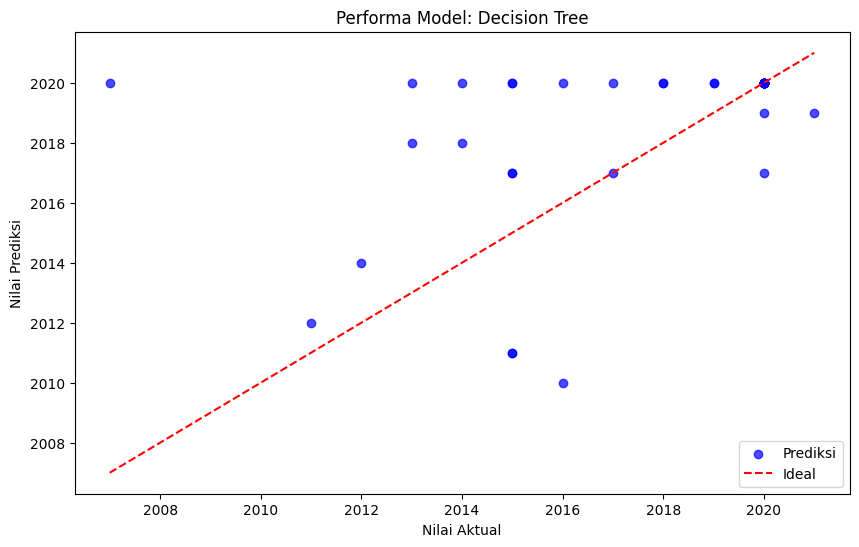


--- Visualisasi Performa Random Forest ---


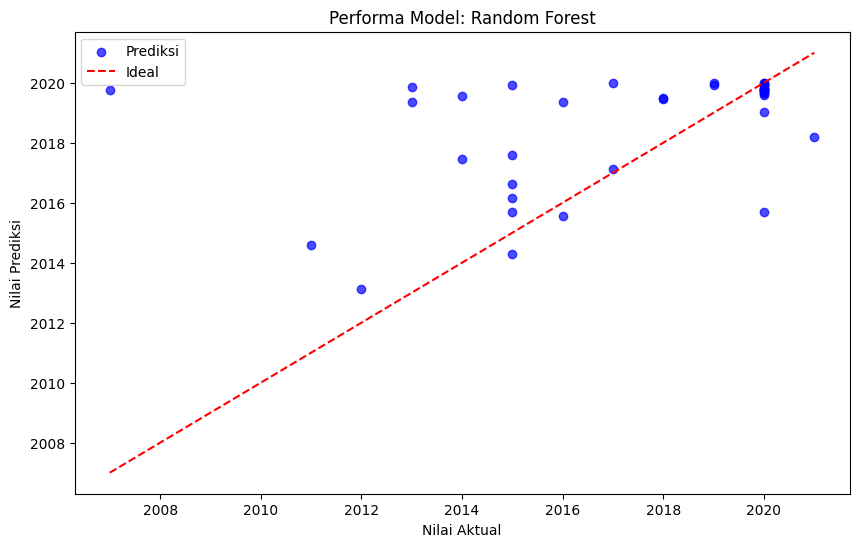

In [70]:
# Visualisasi untuk Decision Tree
print("\n--- Visualisasi Performa Decision Tree ---")
plot_model_performance(y_test, dt_y_pred, "Decision Tree")

# Visualisasi untuk Random Forest
print("\n--- Visualisasi Performa Random Forest ---")
plot_model_performance(y_test, rf_y_pred, "Random Forest")

In [71]:
# Bandingkan MAE dan R² kedua model
performance_metrics = {
    'Model': ['Decision Tree', 'Random Forest'],
    'MAE': [dt_mae, rf_mae],
    'R²': [dt_r2, rf_r2]
}

performance_df = pd.DataFrame(performance_metrics)
print("\nTabel Perbandingan Performa Model:")
print(performance_df)



Tabel Perbandingan Performa Model:
           Model       MAE        R²
0  Decision Tree  2.179487 -0.152052
1  Random Forest  1.904359  0.033902


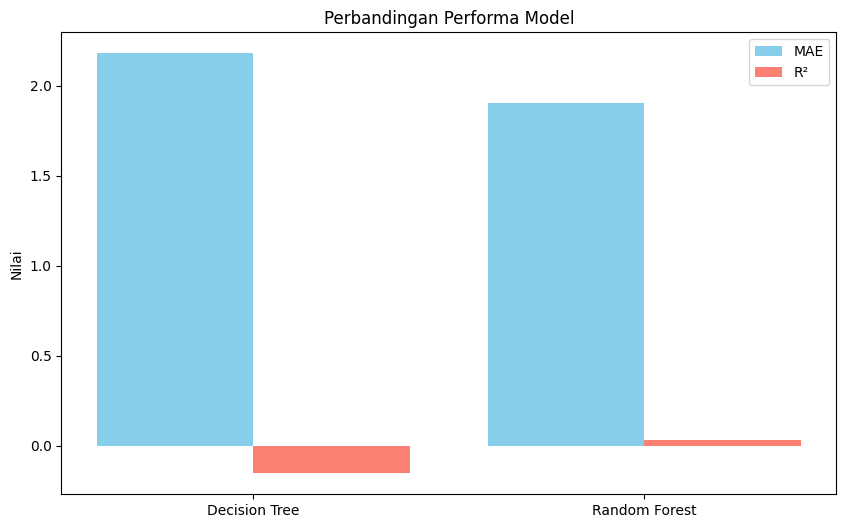

In [72]:
# Visualisasi perbandingan performa
plt.figure(figsize=(10, 6))
x = np.arange(len(performance_df['Model']))
width = 0.4

plt.bar(x - width/2, performance_df['MAE'], width, label='MAE', color='skyblue')
plt.bar(x + width/2, performance_df['R²'], width, label='R²', color='salmon')

plt.xticks(x, performance_df['Model'])
plt.title('Perbandingan Performa Model')
plt.ylabel('Nilai')
plt.legend()
plt.show()


Diskusi Hasil dan Kesimpulan

Diskusi Hasil:

Decision Tree: Memberikan hasil prediksi yang baik, namun lebih cenderung overfitting pada data latih.

Random Forest: Memberikan hasil yang lebih stabil dan akurat, karena memanfaatkan banyak pohon keputusan.


Kesimpulan:

Model Random Forest lebih direkomendasikan untuk memprediksi kasus pembunuhan berdasarkan dataset ini.


Proses EDA menunjukkan bahwa ada korelasi signifikan antara jumlah kasus pembunuhan dan angka kejadian per wilayah.